In [163]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json # in order to work with json files
import geojson # in order to work with geojson files
from area import area #2 calculate the area of the zip code polygons


In [164]:
df_raw = pd.read_csv("data\eda.csv")
print(df_raw.shape)
df_processed = df_raw.copy()
df_raw.head()

(21597, 21)


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price,date
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,221900.000,2014-10-13
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,538000.000,2014-12-09
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,180000.000,2015-02-25
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,604000.000,2014-12-09
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,510000.000,2015-02-18


In [165]:
df_processed[df_processed.duplicated("id", keep = False)]#The 177 duplicates just deviate in price and date (resoled, mb renovated)
df_processed = df_processed.sort_values(by="date", ascending=False).drop_duplicates(subset="id", keep="first")
df_processed.reset_index(drop=True, inplace=True)

In [166]:
df_processed.columns = df_processed.columns.str.lower().str.replace(" ", "_")
df_processed["date"] = pd.to_datetime(df_processed["date"], format="%Y-%m-%d", errors="coerce")# date is an object, but should be a datetime
df_processed.dtypes # now date is a datetime

id                        int64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                  float64
waterfront              float64
view                    float64
condition                 int64
grade                     int64
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated            float64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
price                   float64
date             datetime64[ns]
dtype: object

In [ ]:
#Overview
fig_scatter = px.scatter_mapbox(
    df_processed,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=9,
    height=1000,
    title="Locations of the sold Houses"
)

fig_scatter.update_layout(mapbox_style="open-street-map")
fig_scatter.show()

In [250]:
#houses with waterfront

df_waterfront = df_processed[df_processed["waterfront"] == 1] #df houses with waterfront

print("Number of houses with waterfront: ", df_waterfront.shape[0])

fig_scatter_waterfront = px.scatter_mapbox(
    df_waterfront,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=9,
    height=1000,
    title="Locations of the sold Houses with waterfront"
)

fig_scatter_waterfront.update_layout(mapbox_style="open-street-map")
fig_scatter_waterfront.show()


Number of houses with waterfront:  146


Number of isolated houses:  5152


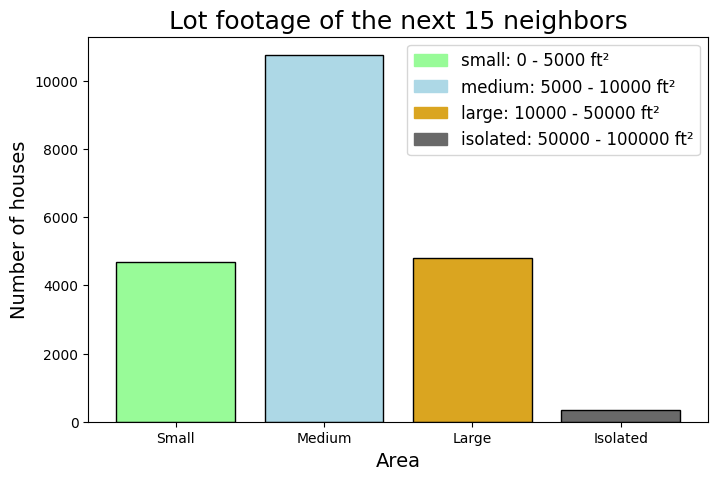

In [242]:
#isolated houses: sqft_lot15 
small = 5000
medium = 10000
large = 50000
isolated = 100000

df_isolated_small = df_processed[(df_processed["sqft_lot15"] < small)]
df_isolated_medium = df_processed[(df_processed["sqft_lot15"] < medium) & (df_processed["sqft_lot15"] > small)]
df_isolated_large = df_processed[(df_processed["sqft_lot15"] < large) & (df_processed["sqft_lot15"] > medium)] 
df_isolated_isolated = df_processed[df_processed["sqft_lot15"] > isolated] 

y = [df_isolated_small.count()[0], df_isolated_medium.count()[0], df_isolated_large.count()[0], df_isolated_isolated.count()[0]]
x = ["Small", "Medium", "Large", "Isolated"]

plt.bar(x,y, color= ("palegreen", "lightblue", "goldenrod", "dimgray"), edgecolor="black")
plt.title('Lot footage of the next 15 neighbors', fontsize=18)
plt.xlabel('Area', fontsize=14)
plt.ylabel('Number of houses', fontsize=14)
colors = {"small: 0 - 5000 ft²":"palegreen", "medium: 5000 - 10000 ft²" :"lightblue", "large: 10000 - 50000 ft²" : "goldenrod", "isolated: 50000 - 100000 ft²" : "dimgray"}         
labels = list(colors.keys())
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
plt.legend(handles, labels, fontsize=12)

nr_isolated_houses = df_isolated_large.count()[0] + df_isolated_isolated.count()[0]
print("Number of isolated houses: ", nr_isolated_houses)

In [249]:
#Number of nice houses
df_nice_houses = df_processed[df_processed["grade"]>=7].count()[0] # 6.5 is the average grade, so we can say that houses with a grade of 7 are above average and therefore nice.
print("Number of nice houses: ", df_nice_houses)

Number of nice houses:  19163


In [253]:
# Disctance to center
center_lat = 47.606086
center_long = -122.332911

from math import radians, cos, sin, asin, sqrt



In [262]:
def haversine_np(lon1, lat1, lon2, lat2):
   
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6378.137 * c
    return km
# Calculate the distance from the center for each entry in df_processed
df_processed['distance_from_center'] = haversine_np(
    df_processed['long'], 
    df_processed['lat'], 
    center_long, 
    center_lat
)

# Create a new DataFrame with id and calculated distance
df_distance = df_processed[['id', 'distance_from_center']].copy()
df_distance.sort_values(by="distance_from_center", ascending=True, inplace=True)
df_center_houses = df_distance[df_distance["distance_from_center"] < 10].count()[0] # houses within 5 km from the center

In [244]:
df_processed["grade"].unique

<bound method Series.unique of 0         8
1         6
2         7
3         6
4         8
         ..
21415     7
21416    10
21417     7
21418     8
21419     8
Name: grade, Length: 21420, dtype: int64>

In [161]:


with open("zip-codes_seattle_better.geojson") as f: # install geojson with pip install geojson first and the area package with pip install area
    geojson_data_better = geojson.load(f)

In [ ]:
geojson_data_better["features"][0]["properties"] # check the properties of the first feature in the geojson file

In [ ]:
with open("zip-codes_seattle.geojson") as f: # install geojson with pip install geojson first and the area package with pip install area
    geojson_data = geojson.load(f)

# Calculate the area for each polygon
polygon_areas = []
for feature in geojson_data['features']:
    polygon = feature['geometry']
    polygon_area = area(polygon)
    polygon_areas.append({
        'zipcode': feature['properties']['ZCTA5CE10'],  # Adjust the property key if needed
        'area': polygon_area
    })
# Convert the results to a DataFrame
df_polygon_areas = pd.DataFrame(polygon_areas)
print(df_polygon_areas)




KeyError: 'ZCTA5CE10'

Text(0, 0.5, 'Zip Code')

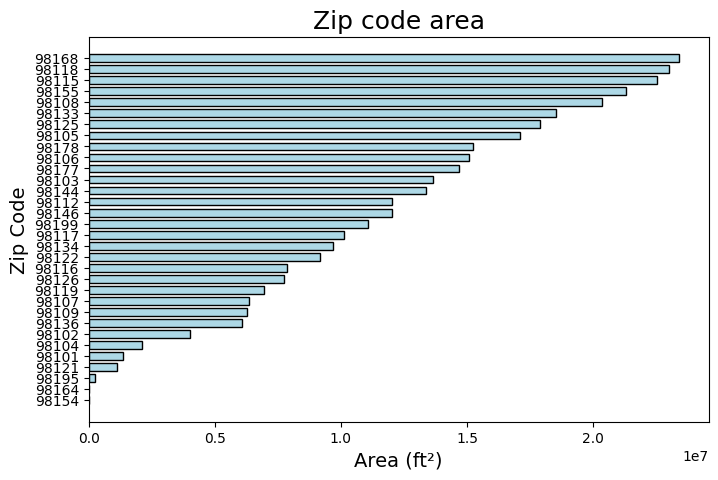

In [135]:
df_polygon_areas_sorted = df_polygon_areas.sort_values('area')
x = df_polygon_areas_sorted["zipcode"]
y = df_polygon_areas_sorted["area"]
plt.barh(x,y, color="lightblue", edgecolor="black", align='center', height=0.7)
plt.title('Zip code area', fontsize=18)
plt.xlabel('Area (ft²)', fontsize=14)
plt.ylabel('Zip Code', fontsize=14)


In [157]:
isolated_zipcodes = df_polygon_areas.sort_values('area', ascending=False)[:15]['zipcode'] # returns the largest zip code areas 
print(isolated_zipcodes)
center_zipcodes = df_polygon_areas.sort_values('area', ascending=True)[:10]['zipcode'] # returns the smallest zip code areas
print(center_zipcodes)

31    98168
24    98118
23    98115
18    98155
15    98108
14    98133
26    98125
17    98105
16    98178
29    98106
19    98177
20    98103
1     98144
22    98112
28    98146
Name: zipcode, dtype: object
8     98154
9     98164
3     98195
7     98121
5     98101
21    98104
6     98102
0     98136
2     98109
12    98107
Name: zipcode, dtype: object


In [158]:
# Plot highlighting isolated_zipcodes
df_processed['highlight_isolated'] = np.where(
    df_processed['zipcode'].astype(str).isin(isolated_zipcodes.astype(str)), 'red', 'blue'
)

fig_isolated = px.choropleth_mapbox(
    df_processed,
    geojson=geojson_data,
    locations="zipcode",
    featureidkey="properties.ZCTA5CE10",
    color="highlight_isolated",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_map={"red": "red", "blue": "blue"},  # Red for isolated, blue for others
    mapbox_style="carto-positron",
    zoom=9,
    center={"lat": df_processed["lat"].mean(), "lon": df_processed["long"].mean()},
    title="Zip Code Borders Highlighting Isolated Areas"
)

fig_isolated.update_geos(fitbounds="locations", visible=False)
fig_isolated.show()

# Plot highlighting center_zipcodes
df_processed['highlight_center'] = np.where(
    df_processed['zipcode'].astype(str).isin(center_zipcodes.astype(str)), 'green', 'blue'
)

fig_center = px.choropleth_mapbox(
    df_processed,
    geojson=geojson_data,
    locations="zipcode",
    featureidkey="properties.ZCTA5CE10",
    color="highlight_center",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_map={"green": "green", "blue": "blue"},  # Green for center, blue for others
    mapbox_style="carto-positron",
    zoom=9,
    center={"lat": df_processed["lat"].mean(), "lon": df_processed["long"].mean()},
    title="Zip Code Borders Highlighting Center Areas"
)

fig_center.update_geos(fitbounds="locations", visible=False)
fig_center.show()